In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
features = pd.read_csv("src/data/training/raw/merged_training_data.csv")

In [3]:
features['mix__sd_od_history_to_kyc_ratio'] = features['od__history_length_days'] / features['sd__age_since_first_kyc']

In [4]:
features = features.drop(columns=['user_id', 'default_date'])
features = features.loc[:, ~features.columns.str.startswith('dn__', 'madrid__')]

/var/folders/1f/pct68c2j21dd7jgky0y_thb80000gp/T/ipykernel_28256/2097045937.py:2: FutureWarning: Allowing a non-bool 'na' in obj.str.startswith is deprecated and will raise in a future version.
  features = features.loc[:, ~features.columns.str.startswith('dn__', 'madrid__')]


In [5]:
ordinal_features = [
    "cb__worst_score",
    "gender",
    "cb__most_recent_score",
    "sd__membership_product"
]

ordinal_encoder = OrdinalEncoder(
    categories=[
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__worst_score
        ["MALE", "FEMALE", "NON_BINARY"],                                                                 # gender
        ["A", "B", "C", "D", "E", "F", "G", "M", "N", "O", "P", np.nan],           # cb__most_recent_score
        ["PERSONAL_FLEX", "PERSONAL_STANDARD", "PERSONAL_SMART"
         , "PERSONAL_YOU", "PERSONAL_METAL", "BUSINESS_STANDARD"
         , "BUSINESS_SMART", "BUSINESS_YOU", "BUSINESS_METAL", np.nan]        # sd__membership_product
    ],
    encoded_missing_value=np.nan
)

features[ordinal_features] = ordinal_encoder.fit_transform(
    features[ordinal_features]
)

In [6]:
reg_feats = ['ob__open_limit_ref',
 'ob__avg_util_3m',
 'ob__od_enabled_zero_util_days_6m',
 'sd__age',
 'cb__worst_score',
 'ob__max_util_change_3m',
 'ab__inflow_spike_count_6m',
 'ul__is_expat',
 'ab__avg_bal_3m',
 'ob__max_util_3m',
 'sd__max_daily_logins_6m',
 'ab__days_down_6m',
 'ob__max_to_avg_util_3m_ratio',
 'ab__std_util_3m',
 'ob__std_util_3m']

In [7]:
features_reg = features[reg_feats]

                               feature  year  month        psi
0                   ob__open_limit_ref  2017      1        NaN
1                   ob__open_limit_ref  2017      2        NaN
2                   ob__open_limit_ref  2017      3        NaN
3                   ob__open_limit_ref  2017      4        NaN
4                   ob__open_limit_ref  2017      5        NaN
5                   ob__open_limit_ref  2017      6        NaN
6                   ob__open_limit_ref  2017      7        NaN
7                   ob__open_limit_ref  2017      8        NaN
8                   ob__open_limit_ref  2017      9        NaN
9                   ob__open_limit_ref  2017     10        NaN
10                  ob__open_limit_ref  2017     11   1.165200
11                  ob__open_limit_ref  2017     12   0.505796
12                  ob__open_limit_ref  2018      1   0.540295
13                  ob__open_limit_ref  2018      2   5.096938
14                  ob__open_limit_ref  2018      3   2

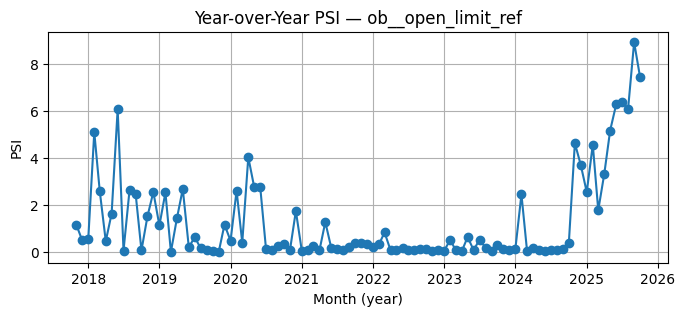

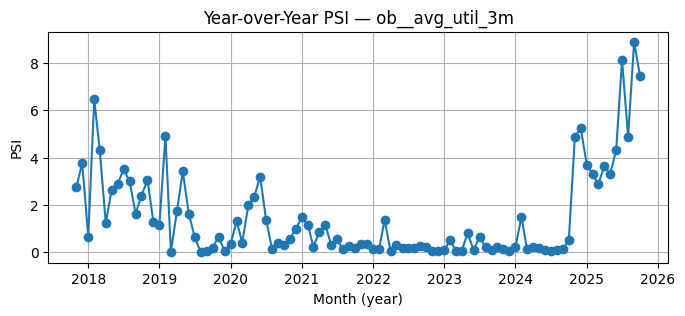

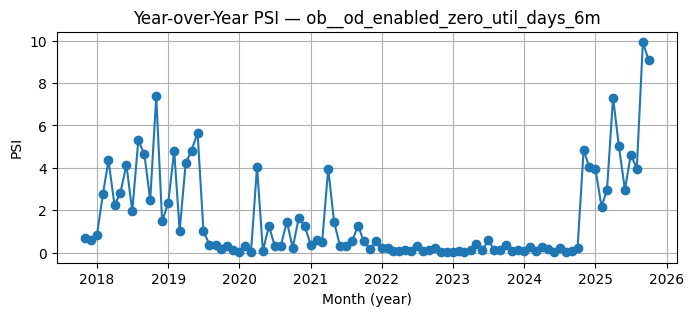

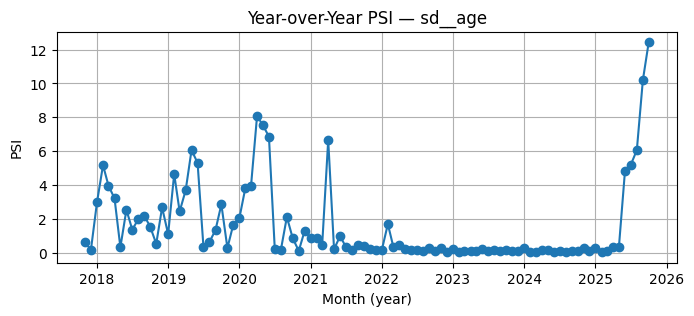

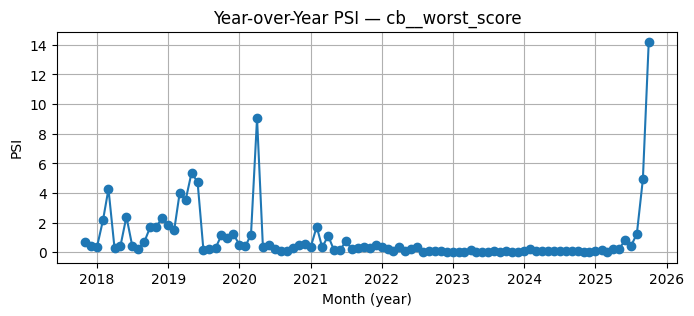

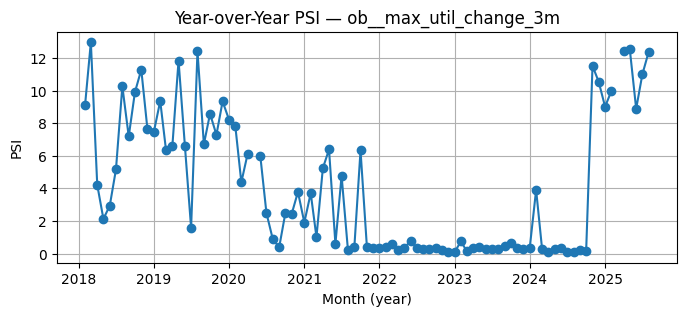

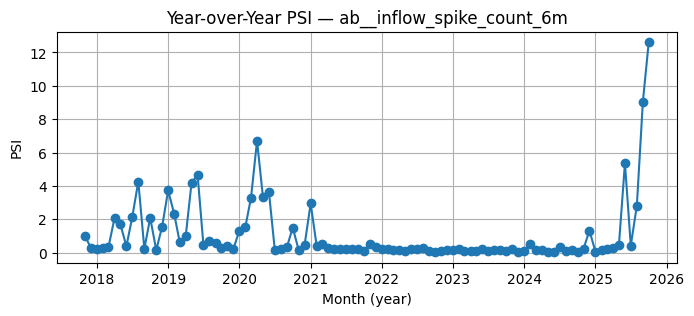

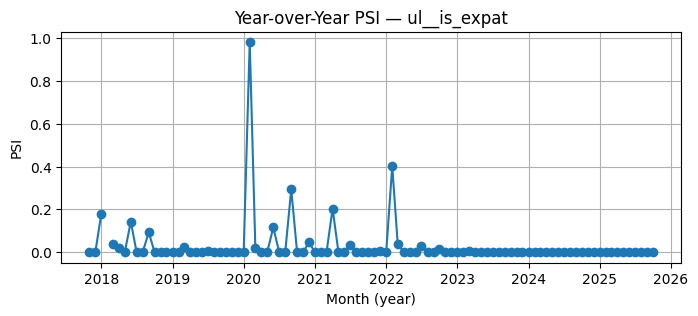

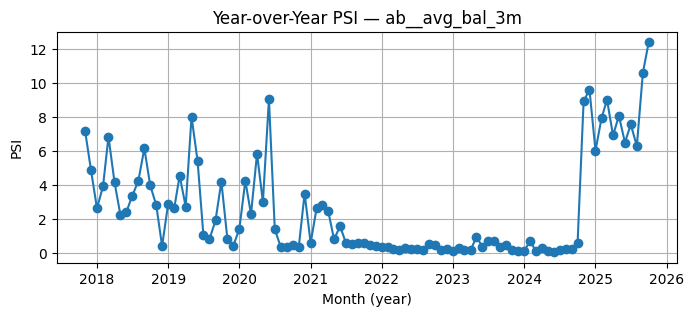

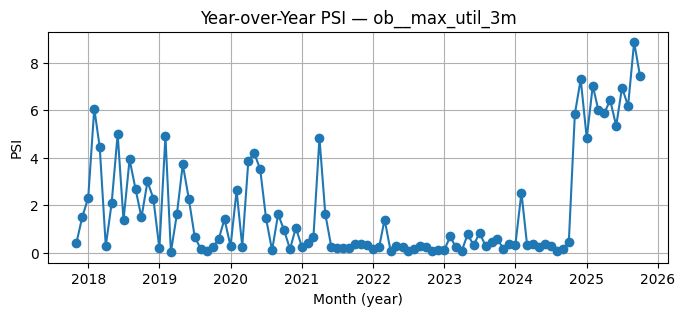

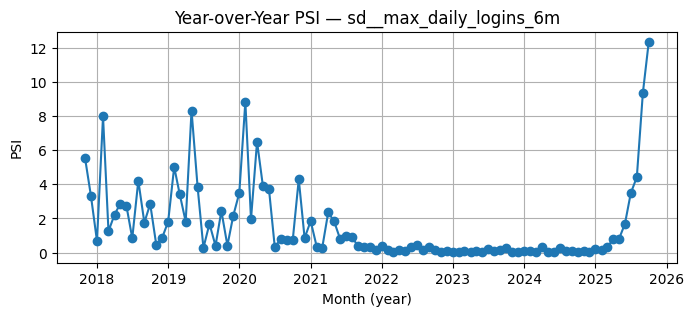

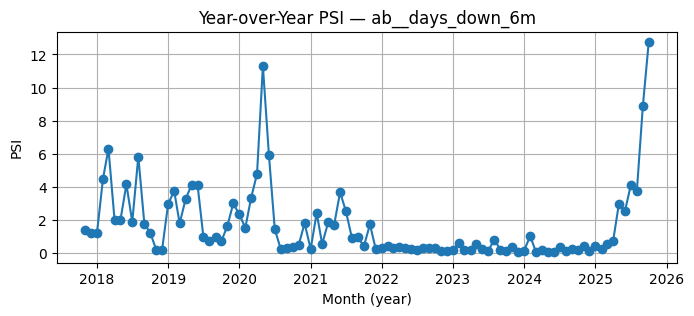

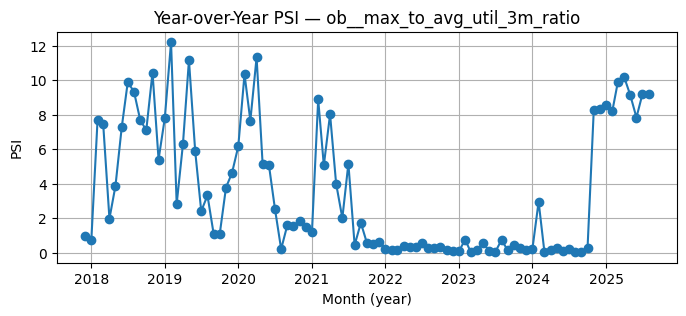

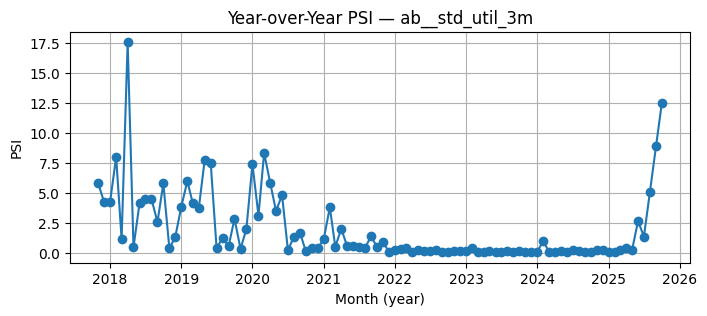

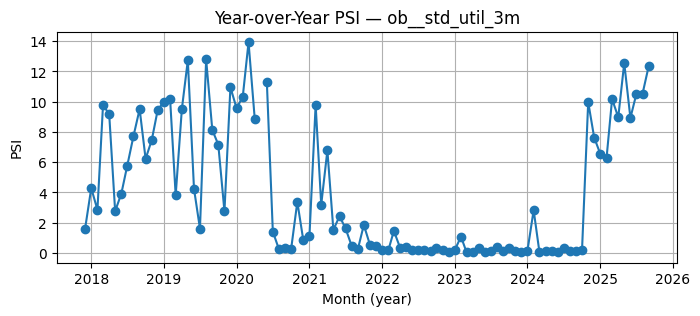

In [25]:
def calculate_psi(expected, actual, buckets=10):
    expected = np.array(pd.Series(expected).dropna()).astype(float)
    actual = np.array(pd.Series(actual).dropna()).astype(float)
    if expected.size == 0 or actual.size == 0:
        return np.nan

    bins = np.unique(np.quantile(expected, np.linspace(0, 1, buckets + 1)))
    if bins.size < 2:
        return np.nan
    exp_perc = np.histogram(expected, bins=bins)[0] / expected.size
    act_perc = np.histogram(actual, bins=bins)[0] / actual.size
    exp_perc = np.where(exp_perc == 0, 1e-6, exp_perc)
    act_perc = np.where(act_perc == 0, 1e-6, act_perc)
    return np.sum((exp_perc - act_perc) * np.log(exp_perc / act_perc))

df = features.copy()
df['reference_date'] = pd.to_datetime(df['reference_date'])
df['year'] = df['reference_date'].dt.year
df['month'] = df['reference_date'].dt.month

features_reg_list = [f for f in features_reg.columns if f != "reference_date"]
feature_list = features_reg_list

rows = []
years = sorted(df['year'].unique())

for feat in feature_list:
    for year in years:
        prev_year = year - 1
        if prev_year not in years:
            continue
        for month in sorted(df['month'].unique()):
            expected = df.loc[(df['year'] == prev_year) & (df['month'] == month), feat]
            actual = df.loc[(df['year'] == year) & (df['month'] == month), feat]
            psi_val = calculate_psi(expected, actual, buckets=10)
            rows.append({"feature": feat, "year": year, "month": month, "psi": psi_val})

psi_df = pd.DataFrame(rows)
psi_pivot = psi_df.pivot_table(index=['year', 'month'], columns='feature', values='psi')

print(psi_df)

for feat in feature_list:
    sub = psi_df[psi_df['feature'] == feat].sort_values(['year', 'month'])
    if sub['psi'].notna().sum() == 0:
        continue
    x = pd.to_datetime(sub['year'].astype(str) + '-' + sub['month'].astype(str) + '-01')
    plt.figure(figsize=(8, 3))
    plt.plot(x, sub['psi'], marker='o')
    plt.title(f'Year-over-Year PSI — {feat}')
    plt.xlabel('Month (year)')
    plt.ylabel('PSI')
    plt.grid(True)
    plt.show()

In [26]:
features['reference_date'] = pd.to_datetime(features['reference_date'])

features['eom'] = features['reference_date'] + pd.offsets.MonthEnd(0)

df_eom_avg = features.groupby('eom').mean().reset_index()

features_reg_list = [feature for feature in features_reg.columns if feature != "reference_date"]

all_features = df_eom_avg[features_reg_list + ['reference_date']]

for feature in all_features:
    plt.figure(figsize=(10, 6))
    
    plt.plot(all_features['reference_date'], all_features[feature], marker='o', linestyle='-', label=feature)
    
    # Add labels, title, and legend
    plt.xlabel('Reference Date')
    plt.ylabel(feature)
    plt.title(f'{feature} Over Time')
    plt.legend()
    plt.grid(True)
    
    # Show the plot
    plt.show()

TypeError: agg function failed [how->mean,dtype->object]

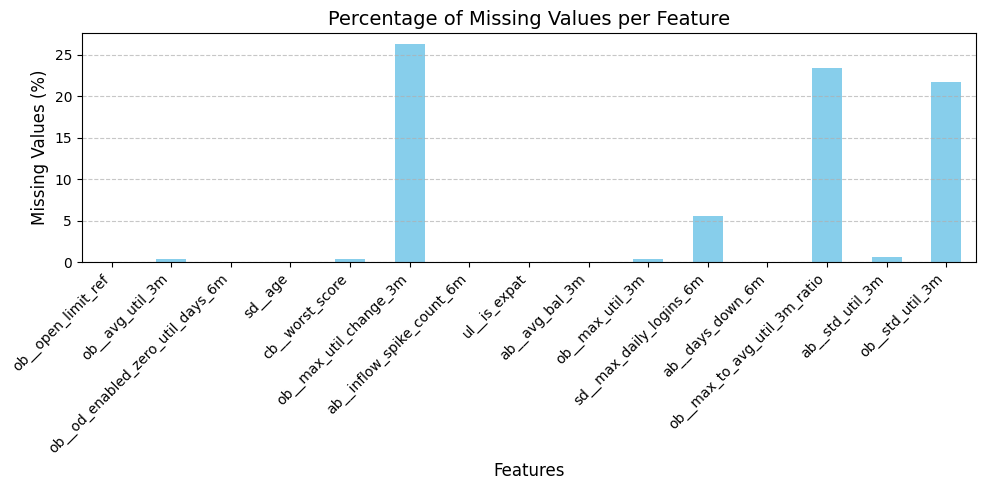

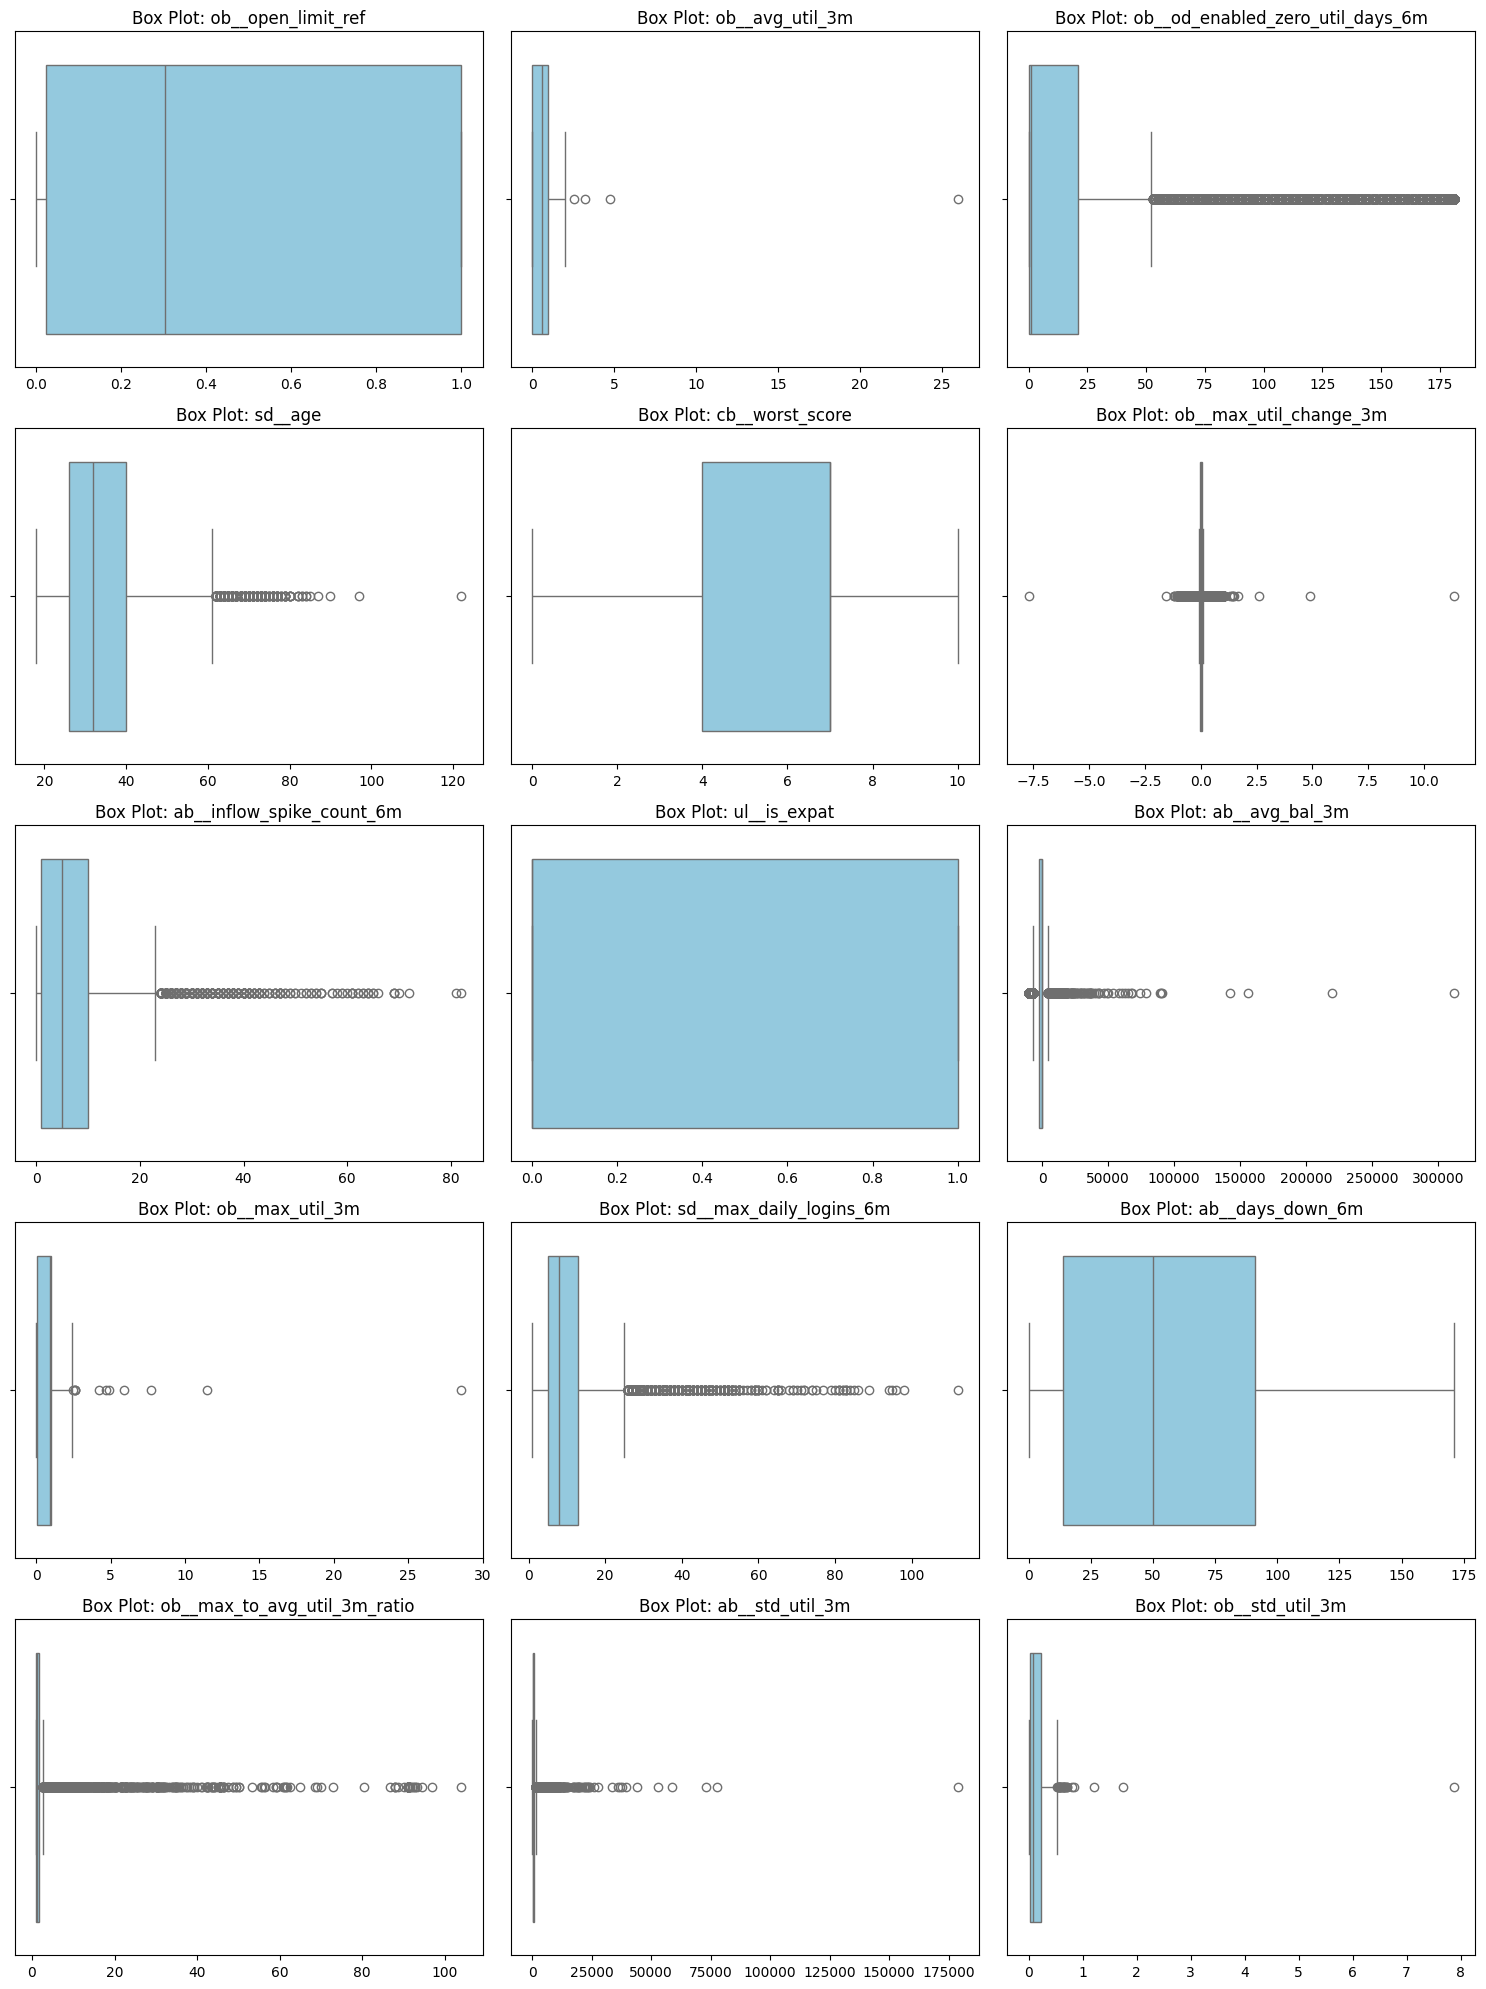

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Assumed variables:
# df: Pandas DataFrame
# features_reg: List of numeric feature names, e.g., ['age', 'income', 'score']


# --- 1. Missing Values Bar Chart ---
plt.figure(figsize=(10, 5))
missing_percent = (features_reg.isnull().mean()) * 100

missing_percent.plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Values per Feature', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Missing Values (%)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# --- 2. Outliers Box Plots ---
num_features = len(features_reg.columns)  # Count columns, not rows
cols = 3
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows), squeeze=False)
axes = axes.flatten()

for i, feature in enumerate(features_reg.columns):
    sns.boxplot(x=features_reg[feature], ax=axes[i], color='skyblue')
    axes[i].set_title(f'Box Plot: {feature}', fontsize=12)
    axes[i].set_xlabel('')

# Clear unused axes
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()